In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import itertools

In [2]:
df = pd.read_csv('../data/Series/international-airline-passengers.csv')
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
df = df.asfreq('MS')

df

,Count
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


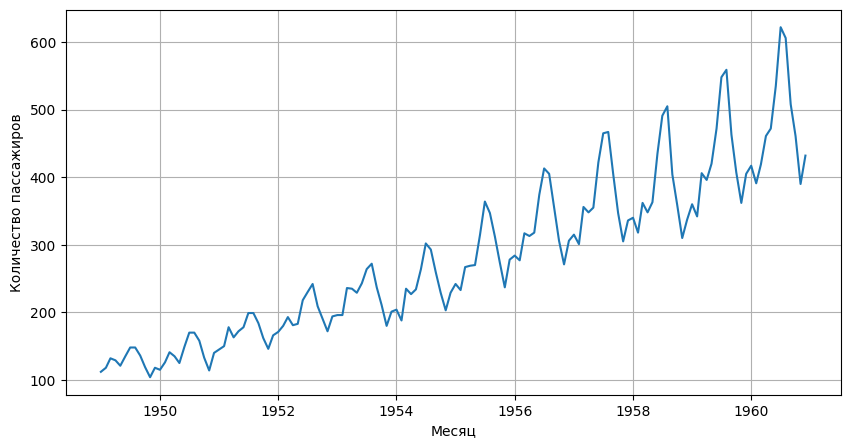

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(df['Count'])
plt.xlabel('Месяц')
plt.ylabel('Количество пассажиров')
plt.grid(True)
plt.show()

In [4]:
result = adfuller(df['Count'])
print('Стационарность ряда')
print('ADF Statistic:', result[0])
print('p-value:',  result[1])

Стационарность ряда
ADF Statistic: 0.815368879206053
p-value: 0.9918802434376411


In [5]:
df['log'] = np.log(df['Count'])
df['diff'] = df['log'].diff()

df

,Count,log,diff
Month,,,
1949-01-01,112,4.718499,NaN
1949-02-01,118,4.770685,0.052186
1949-03-01,132,4.882802,0.112117
1949-04-01,129,4.859812,-0.022990
1949-05-01,121,4.795791,-0.064022
...,...,...,...
1960-08-01,606,6.406880,-0.026060
1960-09-01,508,6.230481,-0.176399
1960-10-01,461,6.133398,-0.097083


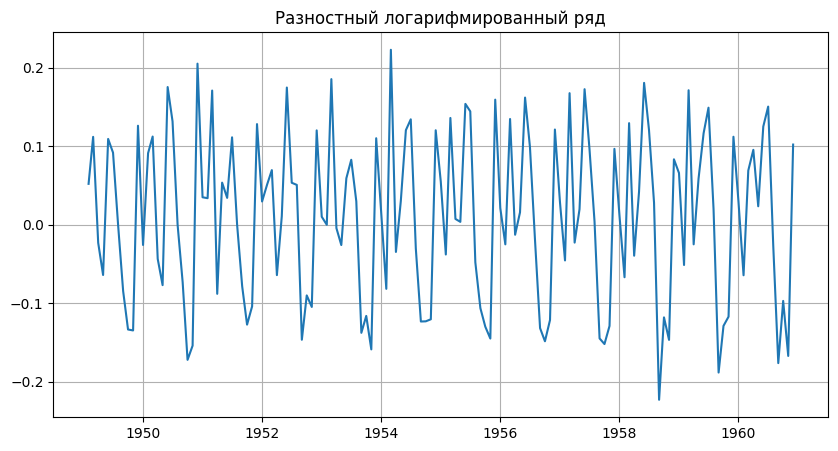

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['diff'])
plt.title('Разностный логарифмированный ряд')
plt.grid(True)
plt.show()

In [7]:
result_diff = adfuller(df['diff'].dropna())
print('Проверка после дифференцирования')
print('ADF Statistic (после дифф.):', result_diff[0])
print('p-value:', result_diff[1])

Проверка после дифференцирования
ADF Statistic (после дифф.): -2.7171305983881098
p-value: 0.07112054815086265


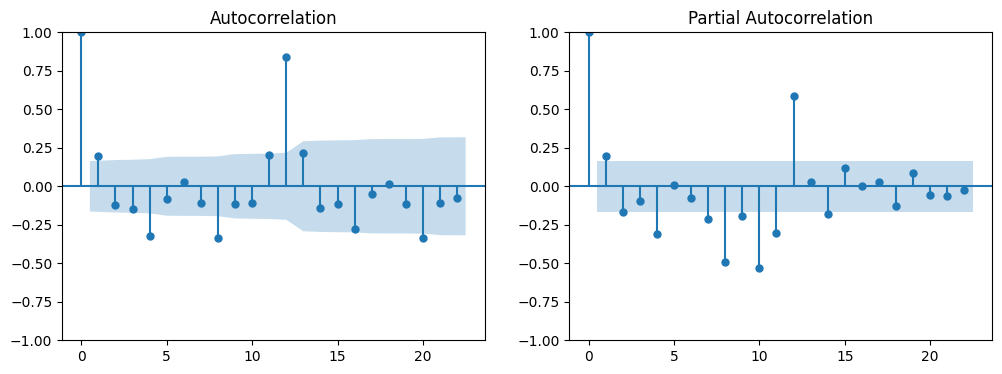

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['diff'].dropna(), ax=ax[0])
plot_pacf(df['diff'].dropna(), ax=ax[1])
plt.show()

In [9]:
# Поиск оптимальных параметров
p = q = range(0, 3)
d = [1]
best_aic = np.inf
best_order = None
best_model = None

for param in itertools.product(p, d, q):
    try:
        model = ARIMA(df['log'], order=param).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = param
            best_model = model
    except:
        continue

print('Лучшие параметры ARIMA:', best_order)
print('AIC:', best_aic)

Лучшие параметры ARIMA: (2, 1, 1)
AIC: -251.46350910259133


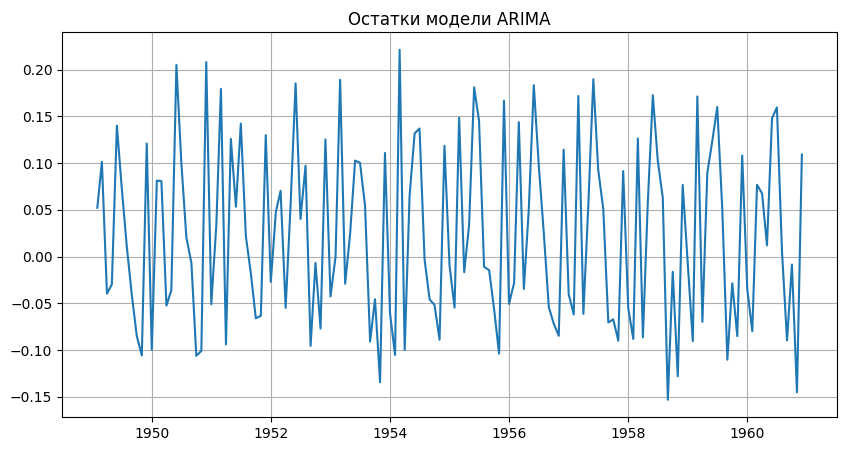

In [10]:
df['pred'] = best_model.predict()
residuals = best_model.resid

plt.figure(figsize=(10, 5))
plt.plot(residuals[1:])
plt.title('Остатки модели ARIMA')
plt.grid(True)
plt.show()

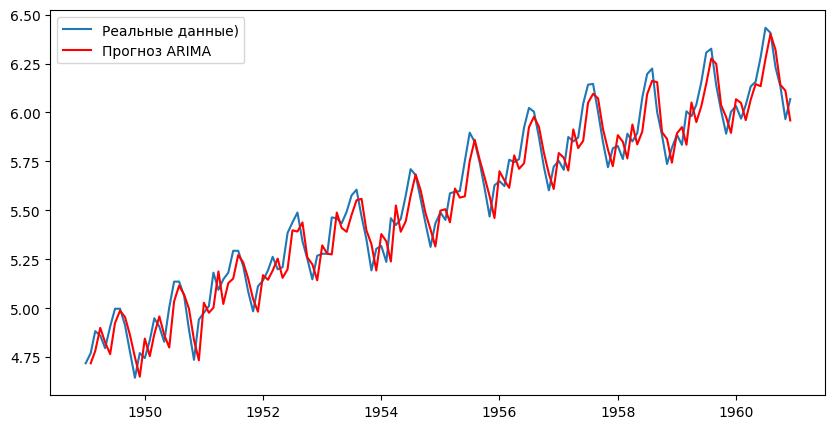

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df['log'], label='Реальные данные)')
plt.plot(df['pred'][1:], color='red', label='Прогноз ARIMA')
plt.legend()
plt.show()

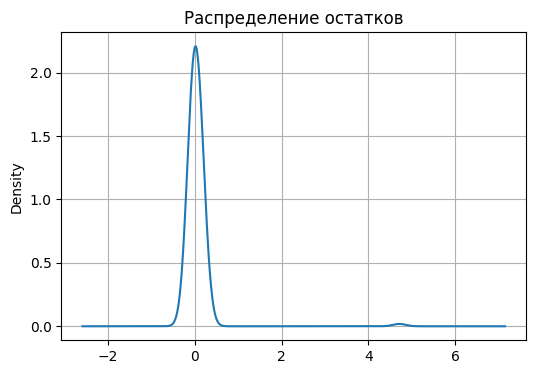

In [12]:
residuals.plot(kind='kde', figsize=(6, 4), title='Распределение остатков')
plt.grid(True)
plt.show()

In [13]:
print('Среднее остатка:', np.mean(residuals))
print('Дисперсия остатков:', np.var(residuals))

Среднее остатка: 0.055377563321488806
Дисперсия остатков: 0.1610029696124217
